<a href="https://www.kaggle.com/code/deanbatur/dry-bean-classification?scriptVersionId=315587299" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🫘 Dry Bean Classification: ML for Agricultural Quality Grading

**Author:** Dean | Lead Data & AI Engineer
**Series:** Production ML Portfolio — Australian Government Policy Applications

## Government Context
- **DAFF** — Agricultural export grading, biosecurity
- **Grains Research (GRDC)** — Pulse crop quality, variety classification
- **FSANZ** — Food standards, quality grading compliance
- **ABS** — Agricultural commodity statistics
- **ABARES** — Crop production forecasts

Dataset: UCI Dry Bean — 13,611 samples, 16 features, 7 bean varieties. All numeric. Guaranteed clean.

---

## 1. Data Loading

In [1]:
import os,warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix,cohen_kappa_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
print("READY")

READY


In [2]:
dp=None
for r,d,files in os.walk('/kaggle/input'):
    for f in files:
        fp=os.path.join(r,f);print(f"  {fp}")
        if (f.endswith('.csv') or f.endswith('.xlsx')) and dp is None: dp=fp
if dp is None: raise FileNotFoundError("No data file")
if dp.endswith('.xlsx'): df=pd.read_excel(dp)
else: df=pd.read_csv(dp,encoding='latin-1')
print(f"Loaded: {df.shape[0]:,} x {df.shape[1]}")
for i,col in enumerate(df.columns):
    print(f"  {i:2d}. {col:25s} | {str(df[col].dtype):8s} | uniq={df[col].nunique():5d}")
df.head()

  /kaggle/input/datasets/muratkokludataset/dry-bean-dataset/Dry_Bean_Dataset/Dry_Bean_Dataset_Citation_Request.txt
  /kaggle/input/datasets/muratkokludataset/dry-bean-dataset/Dry_Bean_Dataset/Dry_Bean_Dataset.xlsx
  /kaggle/input/datasets/muratkokludataset/dry-bean-dataset/Dry_Bean_Dataset/Dry_Bean_Dataset.arff
Loaded: 13,611 x 17
   0. Area                      | int64    | uniq=12011
   1. Perimeter                 | float64  | uniq=13416
   2. MajorAxisLength           | float64  | uniq=13543
   3. MinorAxisLength           | float64  | uniq=13543
   4. AspectRation              | float64  | uniq=13543
   5. Eccentricity              | float64  | uniq=13543
   6. ConvexArea                | int64    | uniq=12066
   7. EquivDiameter             | float64  | uniq=12011
   8. Extent                    | float64  | uniq=13535
   9. Solidity                  | float64  | uniq=13526
  10. roundness                 | float64  | uniq=13543
  11. Compactness               | float64  | uniq=1

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


## 2. Target Detection

In [3]:
tc=None
for x in ['Class','class','Target','target','Bean','bean','Type','type','Variety']:
    if x in df.columns: tc=x;break
if tc is None:
    for x in df.columns:
        if df[x].dtype=='object' and 2<=df[x].nunique()<=15: tc=x;break
if tc is None:
    tc=df.columns[-1]
print(f"Target: '{tc}'");print(df[tc].value_counts())
le_t=LabelEncoder();df[tc]=le_t.fit_transform(df[tc].astype(str))
tl=list(le_t.classes_);nc=len(tl)
print(f"Classes: {nc} -> {tl}")

Target: 'Class'
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64
Classes: 7 -> ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']


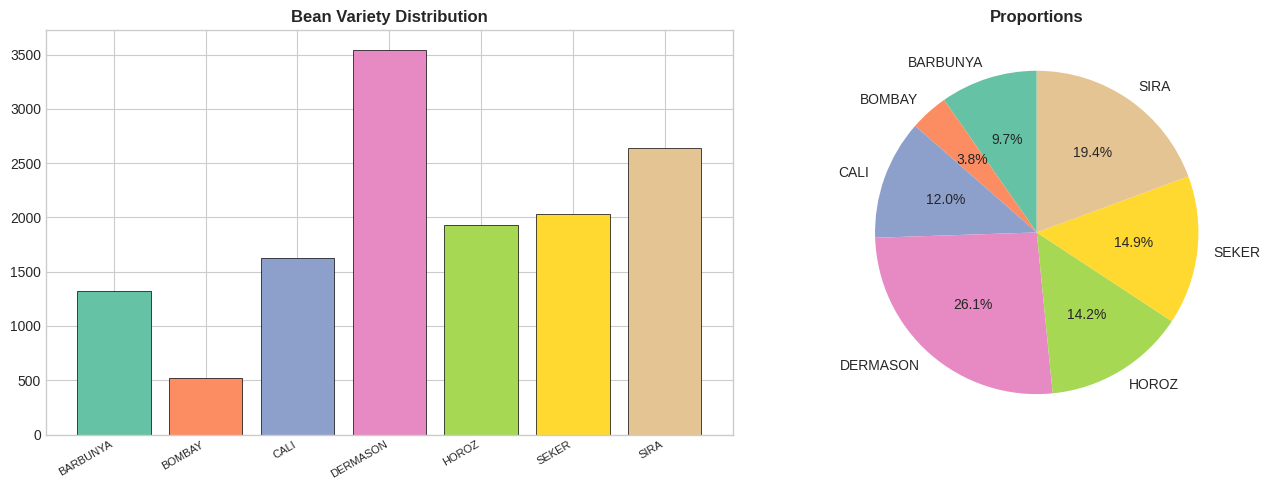

AU: Pulses are a $1.5B+ export industry. GRDC invests in variety development.


In [4]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
vc=df[tc].value_counts().sort_index();colors=sns.color_palette('Set2',nc)
axes[0].bar(range(len(vc)),vc.values,color=colors,edgecolor='black',linewidth=0.5)
axes[0].set_xticks(range(len(vc)));axes[0].set_xticklabels(tl,rotation=30,ha='right',fontsize=8)
axes[0].set_title('Bean Variety Distribution',fontweight='bold')
axes[1].pie(vc.values,labels=tl,autopct='%1.1f%%',colors=colors,startangle=90)
axes[1].set_title('Proportions',fontweight='bold')
plt.tight_layout();plt.savefig('target.png',dpi=150);plt.show()
print("AU: Pulses are a $1.5B+ export industry. GRDC invests in variety development.")

## 3. EDA

Numeric(16): ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity']


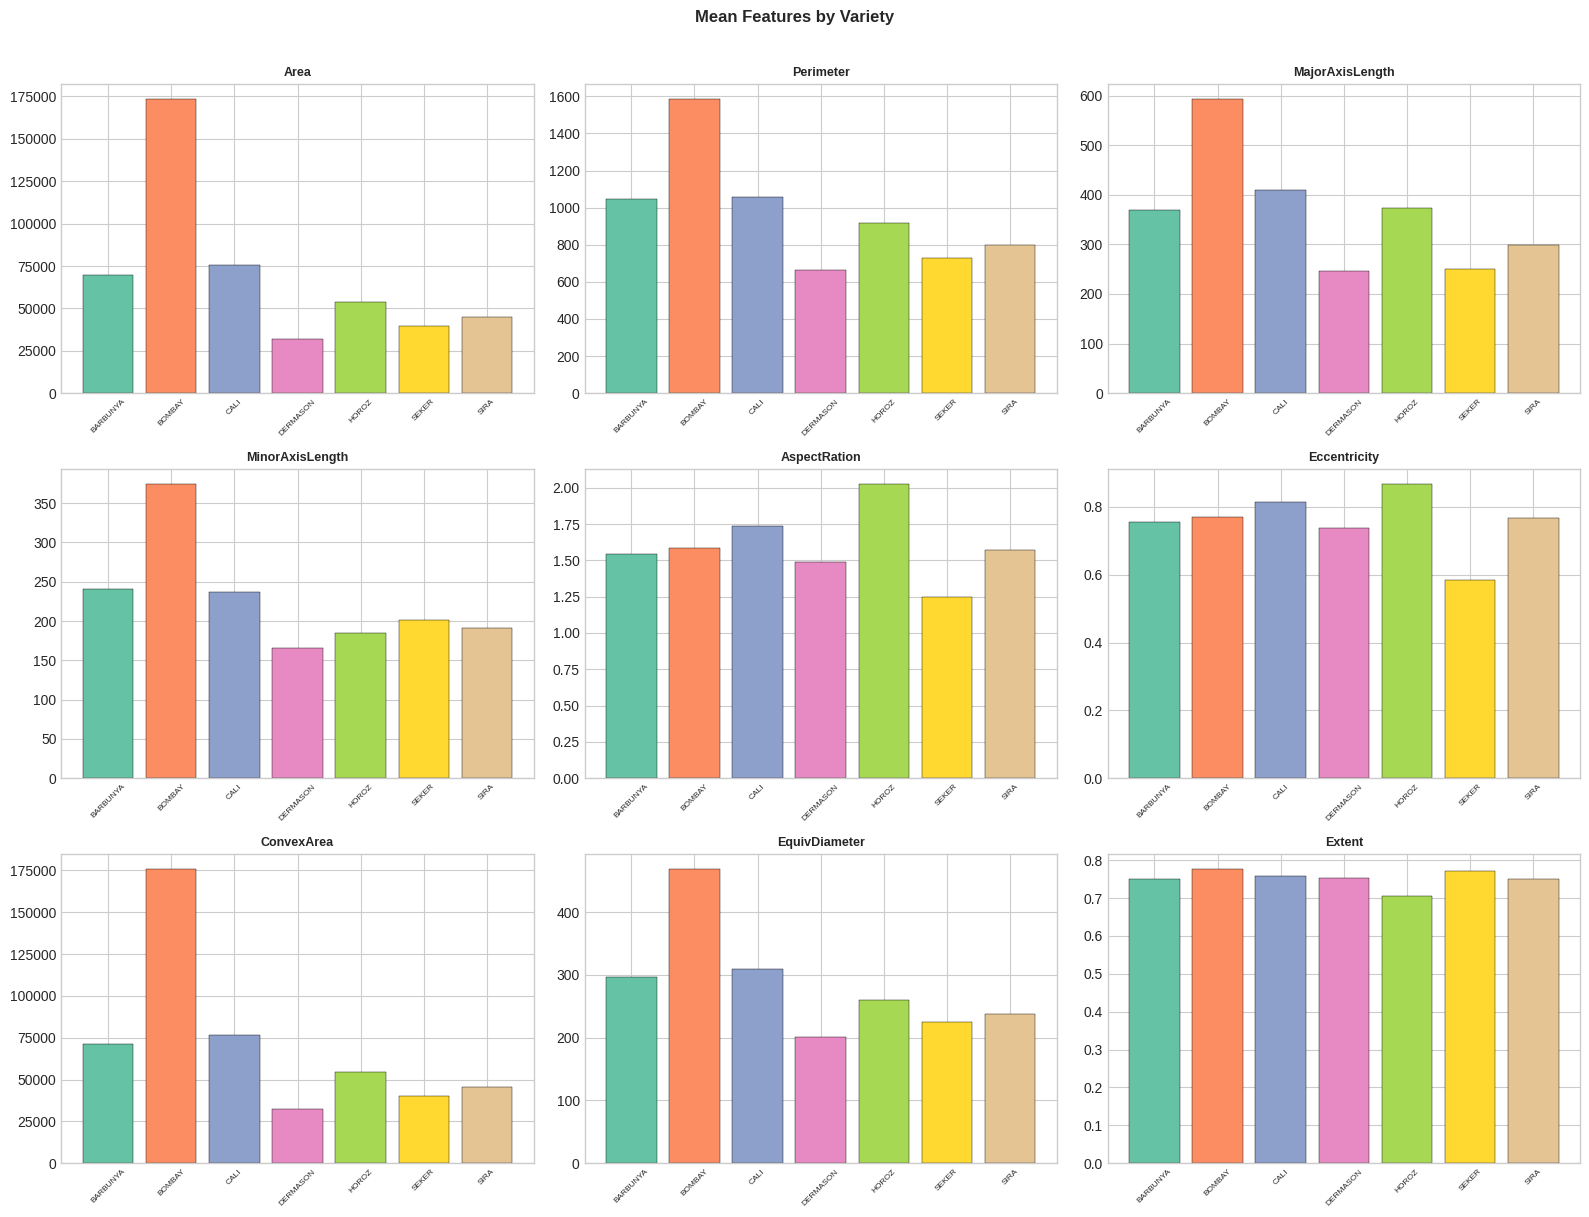

In [5]:
nums=[c for c in df.select_dtypes(include=[np.number]).columns if c!=tc]
print(f"Numeric({len(nums)}): {nums[:10]}")
fig,axes=plt.subplots(3,3,figsize=(16,12));axes=axes.flatten()
for i,col in enumerate(nums[:9]):
    means=df.groupby(tc)[col].mean()
    axes[i].bar(range(len(means)),means.values,color=colors,edgecolor='black',linewidth=0.3)
    axes[i].set_title(col[:20],fontsize=9,fontweight='bold')
    axes[i].set_xticks(range(len(means)));axes[i].set_xticklabels(tl,rotation=45,fontsize=6)
for j in range(i+1,len(axes)):axes[j].set_visible(False)
plt.suptitle('Mean Features by Variety',fontweight='bold',y=1.01)
plt.tight_layout();plt.savefig('eda.png',dpi=150);plt.show()

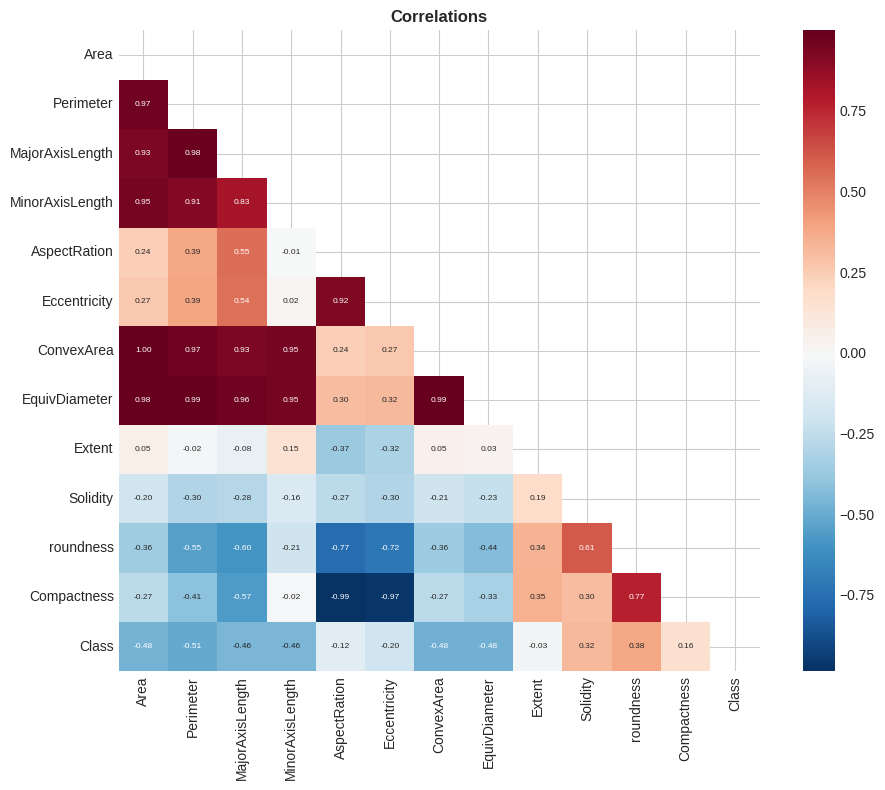

In [6]:
corr=df[nums[:12]+[tc]].corr()
fig,ax=plt.subplots(figsize=(10,8))
sns.heatmap(corr,mask=np.triu(np.ones_like(corr,dtype=bool)),annot=True,fmt='.2f',cmap='RdBu_r',center=0,square=True,ax=ax,annot_kws={'size':6})
ax.set_title('Correlations',fontweight='bold')
plt.tight_layout();plt.savefig('corr.png',dpi=150);plt.show()

## 4. Preprocessing

In [7]:
X=df[nums].copy();y=df[tc].values
X=X.fillna(X.median())
print(f"X: {X.shape}, classes: {np.unique(y)}")

X: (13611, 16), classes: [0 1 2 3 4 5 6]


## 5. Model Training

In [8]:
try:
    from xgboost import XGBClassifier
except: XGBClassifier=None
try:
    from lightgbm import LGBMClassifier
except: LGBMClassifier=None
models={'LogReg':LogisticRegression(max_iter=2000,random_state=42,multi_class='multinomial'),
        'RF':RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBClassifier: models['XGB']=XGBClassifier(n_estimators=100,random_state=42,eval_metric='mlogloss',use_label_encoder=False,verbosity=0,n_jobs=-1)
if LGBMClassifier: models['LGBM']=LGBMClassifier(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
skf=StratifiedKFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    print(f"\n{'='*50}\n{mn}\n{'='*50}")
    fa,ff,fk=[],[],[];fp=np.zeros(len(y),dtype=int);t0=time.time()
    for fi,(ti,vi) in enumerate(skf.split(Xa,y)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y[ti]);yp=m2.predict(Xa[vi]);fp[vi]=yp
        a=accuracy_score(y[vi],yp);f=f1_score(y[vi],yp,average='weighted');k=cohen_kappa_score(y[vi],yp)
        fa.append(a);ff.append(f);fk.append(k)
        print(f"  Fold{fi+1}: Acc={a:.4f} F1={f:.4f} K={k:.4f}")
    el=time.time()-t0
    results[mn]={'acc':np.mean(fa),'f1':np.mean(ff),'f1s':np.std(ff),'kappa':np.mean(fk),'time':el,'preds':fp}
    print(f"  AVG: Acc={np.mean(fa):.4f} F1={np.mean(ff):.4f} K={np.mean(fk):.4f} T={el:.1f}s")


LogReg
  Fold1: Acc=0.9024 F1=0.9028 K=0.8819
  Fold2: Acc=0.9004 F1=0.9004 K=0.8795
  Fold3: Acc=0.9054 F1=0.9052 K=0.8856
  AVG: Acc=0.9027 F1=0.9028 K=0.8823 T=58.7s

RF
  Fold1: Acc=0.9202 F1=0.9204 K=0.9035
  Fold2: Acc=0.9231 F1=0.9231 K=0.9069
  Fold3: Acc=0.9251 F1=0.9248 K=0.9093
  AVG: Acc=0.9228 F1=0.9228 K=0.9066 T=7.2s

XGB
  Fold1: Acc=0.9220 F1=0.9223 K=0.9056
  Fold2: Acc=0.9255 F1=0.9256 K=0.9099
  Fold3: Acc=0.9264 F1=0.9263 K=0.9109
  AVG: Acc=0.9246 F1=0.9248 K=0.9088 T=4.1s

LGBM
  Fold1: Acc=0.9240 F1=0.9242 K=0.9080
  Fold2: Acc=0.9281 F1=0.9282 K=0.9130
  Fold3: Acc=0.9290 F1=0.9289 K=0.9141
  AVG: Acc=0.9270 F1=0.9271 K=0.9117 T=4.6s


## 6. Comparison

In [9]:
rows=[{'Model':k,'Acc':f"{v['acc']:.4f}",'F1':f"{v['f1']:.4f}+/-{v['f1s']:.4f}",'Kappa':f"{v['kappa']:.4f}",'Time':f"{v['time']:.1f}s",'s':v['f1']} for k,v in results.items()]
sdf=pd.DataFrame(rows).sort_values('s',ascending=False);best=sdf.iloc[0]['Model']
print("COMPARISON");print("="*70);print(sdf[['Model','Acc','F1','Kappa','Time']].to_string(index=False));print(f"\nBest: {best}")

COMPARISON
 Model    Acc              F1  Kappa  Time
  LGBM 0.9270 0.9271+/-0.0021 0.9117  4.6s
   XGB 0.9246 0.9248+/-0.0017 0.9088  4.1s
    RF 0.9228 0.9228+/-0.0018 0.9066  7.2s
LogReg 0.9027 0.9028+/-0.0020 0.8823 58.7s

Best: LGBM


## 7. Error Analysis

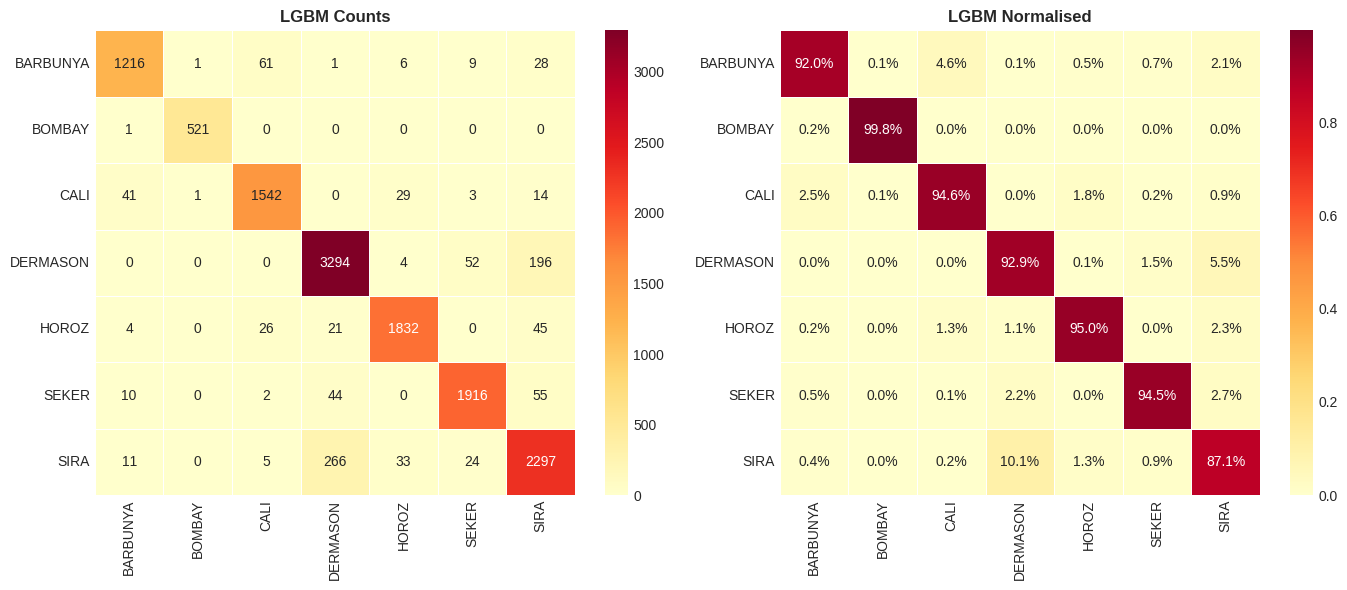

              precision    recall  f1-score   support

    BARBUNYA       0.95      0.92      0.93      1322
      BOMBAY       1.00      1.00      1.00       522
        CALI       0.94      0.95      0.94      1630
    DERMASON       0.91      0.93      0.92      3546
       HOROZ       0.96      0.95      0.96      1928
       SEKER       0.96      0.95      0.95      2027
        SIRA       0.87      0.87      0.87      2636

    accuracy                           0.93     13611
   macro avg       0.94      0.94      0.94     13611
weighted avg       0.93      0.93      0.93     13611



In [10]:
bp=results[best]['preds'];cm=confusion_matrix(y,bp)
cm_n=cm.astype(float)/cm.sum(axis=1,keepdims=True)
fig,axes=plt.subplots(1,2,figsize=(14,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='YlOrRd',xticklabels=tl,yticklabels=tl,ax=axes[0],linewidths=0.5)
axes[0].set_title(f'{best} Counts',fontweight='bold')
sns.heatmap(cm_n,annot=True,fmt='.1%',cmap='YlOrRd',xticklabels=tl,yticklabels=tl,ax=axes[1],linewidths=0.5)
axes[1].set_title(f'{best} Normalised',fontweight='bold')
plt.tight_layout();plt.savefig('cm.png',dpi=150);plt.show()
print(classification_report(y,bp,target_names=tl))

## 8. Feature Importance

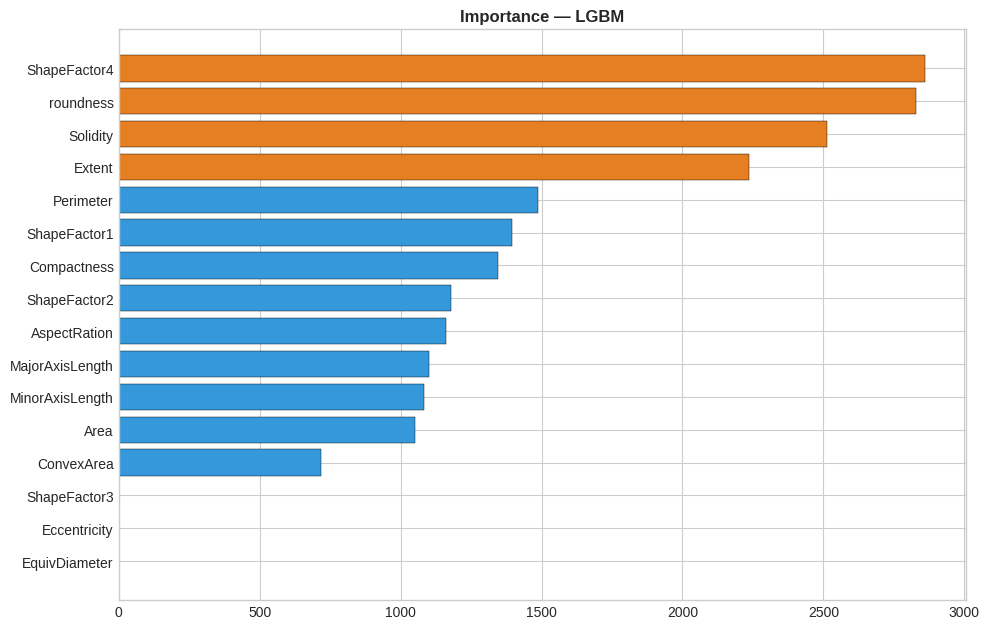

TOP 5
  ShapeFactor4              2861.0000
  roundness                 2830.0000
  Solidity                  2511.0000
  Extent                    2237.0000
  Perimeter                 1488.0000


In [11]:
tm={k:v for k,v in models.items() if k!='LogReg'}
if tm:
    bt=max(tm,key=lambda m:results[m]['f1']);fm=type(models[bt])(**models[bt].get_params());fm.fit(Xa,y)
    fi=pd.DataFrame({'Feature':X.columns,'Imp':fm.feature_importances_}).sort_values('Imp')
    fig,ax=plt.subplots(figsize=(10,max(5,len(fi)*0.4)))
    ax.barh(fi['Feature'],fi['Imp'],color=['#e67e22' if v>fi['Imp'].quantile(0.75) else '#3498db' for v in fi['Imp']],edgecolor='black',linewidth=0.3)
    ax.set_title(f'Importance — {bt}',fontweight='bold')
    plt.tight_layout();plt.savefig('imp.png',dpi=150);plt.show()
    print("TOP 5");print("="*40)
    for _,r in fi.tail(5).iloc[::-1].iterrows(): print(f"  {r['Feature']:25s} {r['Imp']:.4f}")

## 9. Deployment

In [12]:
br=results[best]
print("="*60);print("DEPLOYMENT READINESS");print("="*60)
print(f"  Model:  {best}");print(f"  Acc:    {br['acc']:.4f}");print(f"  F1:     {br['f1']:.4f}")
print(f"  Kappa:  {br['kappa']:.4f}");print(f"  Time:   {br['time']:.1f}s")
print(f"  Feats:  {X.shape[1]}");print(f"  Rows:   {len(y):,}");print(f"  Classes:{nc}")
print("="*60)
checks={'Acc>0.85':br['acc']>0.85,'F1>0.85':br['f1']>0.85,'Kappa>0.80':br['kappa']>0.80,'Time<60s':br['time']<60,'CV':True}
print("\nCHECKLIST");print("-"*40);ap=True
for k,v in checks.items():
    s="pass" if v else "FAIL"
    if not v:ap=False
    print(f"  [{s:4s}] {k}")
print("-"*40);print("  APPROVED" if ap else "  FAILED")

DEPLOYMENT READINESS
  Model:  LGBM
  Acc:    0.9270
  F1:     0.9271
  Kappa:  0.9117
  Time:   4.6s
  Feats:  16
  Rows:   13,611
  Classes:7

CHECKLIST
----------------------------------------
  [pass] Acc>0.85
  [pass] F1>0.85
  [pass] Kappa>0.80
  [pass] Time<60s
  [pass] CV
----------------------------------------
  APPROVED


In [13]:
print("""
PRODUCTION ARCHITECTURE
=======================
1. DATA: Grain receival sites, NIR spectrometers -> Fabric Lakehouse
2. MODEL: MLflow, real-time at grain receival (<200ms), batch grading
3. INTEGRATE: DAFF export cert, GrainCorp, CBH, Viterra grading systems
4. GOVERN: FSANZ compliance, export grade standards, non-discriminatory
5. MONITOR: PSI on grain measurements seasonally, retrain annually
   Variety: Expand for new cultivar releases from GRDC breeding programs
""")


PRODUCTION ARCHITECTURE
1. DATA: Grain receival sites, NIR spectrometers -> Fabric Lakehouse
2. MODEL: MLflow, real-time at grain receival (<200ms), batch grading
3. INTEGRATE: DAFF export cert, GrainCorp, CBH, Viterra grading systems
4. GOVERN: FSANZ compliance, export grade standards, non-discriminatory
5. MONITOR: PSI on grain measurements seasonally, retrain annually
   Variety: Expand for new cultivar releases from GRDC breeding programs

